In [1]:
# CELL 1: Imports & basic setup

import os
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# CELL 2: Mount Google Drive & define paths

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path("/content/drive/MyDrive/mbti-tune")
DATA_DIR = PROJECT_ROOT / "data"

RAW_PLAYLIST_DIR = DATA_DIR / "raw" / "raw_playlists"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

PLAYLIST_EMBEDDINGS_FILE = PROCESSED_DIR / "playlist_embeddings.npy"
PLAYLIST_META_FILE = PROCESSED_DIR / "playlist_metadata.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_PLAYLIST_DIR:", RAW_PLAYLIST_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/mbti-tune
RAW_PLAYLIST_DIR: /content/drive/MyDrive/mbti-tune/data/raw/raw_playlists
PROCESSED_DIR: /content/drive/MyDrive/mbti-tune/data/processed


In [3]:
# CELL 3: Load all playlists (variable-length sequences)

# We will use all numeric columns as features
all_sequences = []      # list of np.ndarray [seq_len, n_features]
all_mbti = []           # list of MBTI labels
all_playlist_ids = []   # list of playlist file names

print("Scanning playlists in:", RAW_PLAYLIST_DIR)

for mbti in sorted(os.listdir(RAW_PLAYLIST_DIR)):
    mbti_path = RAW_PLAYLIST_DIR / mbti
    if not mbti_path.is_dir():
        continue

    for fname in sorted(os.listdir(mbti_path)):
        if not fname.lower().endswith(".csv"):
            continue

        fpath = mbti_path / fname
        df = pd.read_csv(fpath)

        # Keep only numeric columns
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) == 0:
            continue

        seq = df[numeric_cols].values.astype(np.float32)
        if seq.shape[0] == 0:
            continue

        all_sequences.append(seq)
        all_mbti.append(mbti)
        all_playlist_ids.append(fname)

print("Total playlists loaded:", len(all_sequences))
print("Example sequence shape:", all_sequences[0].shape)
print("Example MBTI:", all_mbti[0], "Playlist:", all_playlist_ids[0])
print("Numeric columns used:", list(numeric_cols))


Scanning playlists in: /content/drive/MyDrive/mbti-tune/data/raw/raw_playlists
Total playlists loaded: 324
Example sequence shape: (85, 12)
Example MBTI: ENFJ Playlist: ENFJ (PDB).csv
Numeric columns used: ['#', 'BPM', 'Energy', 'Popularity', 'Dance', 'Acoustic', 'Instrumental', 'Valence', 'Speech', 'Live', 'Loud (Db)', 'Time Signature']


In [4]:
# CELL 4: Fit StandardScaler on all songs across all playlists, then normalize

# Stack all songs to fit scaler
all_songs = np.concatenate(all_sequences, axis=0)  # [total_songs, n_features]
print("All songs stacked shape:", all_songs.shape)

scaler = StandardScaler()
scaler.fit(all_songs)

norm_sequences = []
for seq in all_sequences:
    norm_seq = scaler.transform(seq)
    norm_sequences.append(norm_seq.astype(np.float32))

n_playlists = len(norm_sequences)
n_features = norm_sequences[0].shape[1]
max_len = max(seq.shape[0] for seq in norm_sequences)

print("n_playlists:", n_playlists)
print("n_features:", n_features)
print("max_len:", max_len)


All songs stacked shape: (54343, 12)
n_playlists: 324
n_features: 12
max_len: 2689


In [5]:
# CELL 5: Pad sequences and build Dataset/DataLoader

def pad_sequences(sequences, max_len):
    n = len(sequences)
    n_features = sequences[0].shape[1]
    data = np.zeros((n, max_len, n_features), dtype=np.float32)
    mask = np.zeros((n, max_len), dtype=np.float32)

    for i, seq in enumerate(sequences):
        L = seq.shape[0]
        data[i, :L, :] = seq
        mask[i, :L] = 1.0

    return data, mask

data_padded, mask = pad_sequences(norm_sequences, max_len)
print("Padded data shape:", data_padded.shape)
print("Mask shape:", mask.shape)

class PlaylistDataset(Dataset):
    def __init__(self, data, mask):
        self.data = torch.from_numpy(data)   # [N, T, F]
        self.mask = torch.from_numpy(mask)   # [N, T]

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        x = self.data[idx]   # [T, F]
        m = self.mask[idx]   # [T]
        return x, x, m       # autoencoder: input = target

dataset = PlaylistDataset(data_padded, mask)

# Simple train/val split
val_ratio = 0.1
val_size = int(len(dataset) * val_ratio)
train_size = len(dataset) - val_size

train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

batch_size = 32

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

print("Train size:", len(train_ds), "Val size:", len(val_ds))


Padded data shape: (324, 2689, 12)
Mask shape: (324, 2689)
Train size: 292 Val size: 32


In [6]:
# CELL 6: Define advanced LSTM-based playlist autoencoder

class PlaylistAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, latent_dim=64, num_layers=1):
        super().__init__()
        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
        )
        self.encoder_fc = nn.Linear(hidden_dim, latent_dim)

        self.decoder_lstm = nn.LSTM(
            input_size=latent_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
        )
        self.decoder_fc = nn.Linear(hidden_dim, input_dim)

    def encode(self, x, mask):
        # x: [B, T, F], mask: [B, T]
        lengths = mask.sum(dim=1).long()
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.encoder_lstm(packed)
        h_last = h_n[-1]          # [B, hidden_dim]
        z = self.encoder_fc(h_last)  # [B, latent_dim]
        return z

    def decode(self, z, seq_len):
        # z: [B, latent_dim], seq_len: int
        B = z.size(0)
        z_seq = z.unsqueeze(1).repeat(1, seq_len, 1)  # [B, T, latent_dim]
        out, _ = self.decoder_lstm(z_seq)
        x_hat = self.decoder_fc(out)  # [B, T, F]
        return x_hat

    def forward(self, x, mask):
        z = self.encode(x, mask)
        x_hat = self.decode(z, x.size(1))
        return x_hat, z

input_dim = n_features
latent_dim = 64
hidden_dim = 128

model = PlaylistAutoencoder(input_dim=input_dim,
                            hidden_dim=hidden_dim,
                            latent_dim=latent_dim).to(device)
print(model)


PlaylistAutoencoder(
  (encoder_lstm): LSTM(12, 128, batch_first=True)
  (encoder_fc): Linear(in_features=128, out_features=64, bias=True)
  (decoder_lstm): LSTM(64, 128, batch_first=True)
  (decoder_fc): Linear(in_features=128, out_features=12, bias=True)
)


In [7]:
# CELL 7: Training setup

criterion = nn.MSELoss(reduction="none")  # we'll mask padded timesteps
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

num_epochs = 20

print("num_epochs:", num_epochs)
print("batch_size:", batch_size)
print("latent_dim:", latent_dim)
print("hidden_dim:", hidden_dim)
print("max_len:", max_len)


num_epochs: 20
batch_size: 32
latent_dim: 64
hidden_dim: 128
max_len: 2689


In [8]:
# CELL 8: Train playlist autoencoder & Save weights

def masked_mse_loss(x_hat, x, mask):
    mse = (x_hat - x) ** 2
    mse = mse.mean(dim=2)
    mse = mse * mask
    loss = mse.sum() / mask.sum().clamp(min=1.0)
    return loss

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}
PLAYLIST_MODEL_PATH = PROCESSED_DIR / "playlist_encoder.pth"

for epoch in range(1, num_epochs + 1):
    model.train()
    train_losses = []
    for xb, yb, mb in train_loader:
        xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
        optimizer.zero_grad()
        x_hat, z = model(xb, mb)
        loss = masked_mse_loss(x_hat, yb, mb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb, mb in val_loader:
            xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
            x_hat, z = model(xb, mb)
            loss = masked_mse_loss(x_hat, yb, mb)
            val_losses.append(loss.item())

    val_loss = np.mean(val_losses)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), PLAYLIST_MODEL_PATH) # SAVE WEIGHTS
        best_state = model.state_dict()

    print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

model.load_state_dict(best_state)
print(f"\n✅ Training finished. Weights saved to → {PLAYLIST_MODEL_PATH}")

Epoch 001 | train_loss=0.924723 | val_loss=1.518363
Epoch 002 | train_loss=0.858232 | val_loss=1.389796
Epoch 003 | train_loss=0.829991 | val_loss=1.341612
Epoch 004 | train_loss=0.860821 | val_loss=1.311923
Epoch 005 | train_loss=0.821540 | val_loss=1.274742
Epoch 006 | train_loss=0.815213 | val_loss=1.245957
Epoch 007 | train_loss=0.829138 | val_loss=1.234342
Epoch 008 | train_loss=0.810616 | val_loss=1.225183
Epoch 009 | train_loss=0.790286 | val_loss=1.250442
Epoch 010 | train_loss=0.810838 | val_loss=1.232396
Epoch 011 | train_loss=0.803602 | val_loss=1.256457
Epoch 012 | train_loss=0.784726 | val_loss=1.219182
Epoch 013 | train_loss=0.787592 | val_loss=1.291424
Epoch 014 | train_loss=0.771840 | val_loss=1.220080
Epoch 015 | train_loss=0.817451 | val_loss=1.249077
Epoch 016 | train_loss=0.783044 | val_loss=1.264617
Epoch 017 | train_loss=0.781791 | val_loss=1.236567
Epoch 018 | train_loss=0.790420 | val_loss=1.289994
Epoch 019 | train_loss=0.790296 | val_loss=1.191674
Epoch 020 | 

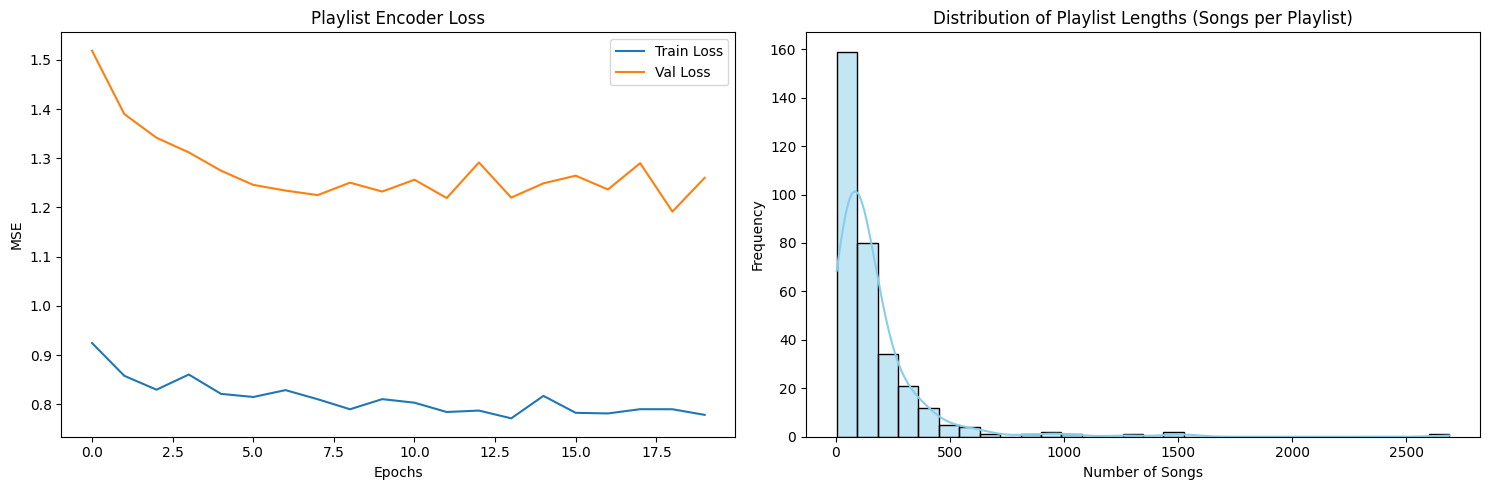

In [9]:
# NEW CELL 8.5: Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# 1. Training History
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Playlist Encoder Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()

# 2. Sequence Length Distribution
plt.subplot(1, 2, 2)
lengths = [len(s) for s in all_sequences]
sns.histplot(lengths, bins=30, kde=True, color='skyblue')
plt.title("Distribution of Playlist Lengths (Songs per Playlist)")
plt.xlabel("Number of Songs")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [10]:
# CELL 9: Generate playlist embeddings and save to .npy + metadata

model.eval()
all_embeddings = []

with torch.no_grad():
    data_tensor = torch.from_numpy(data_padded).to(device)
    mask_tensor = torch.from_numpy(mask).to(device)

    batch_size_eval = 64
    for i in range(0, n_playlists, batch_size_eval):
        xb = data_tensor[i:i+batch_size_eval]
        mb = mask_tensor[i:i+batch_size_eval]
        z = model.encode(xb, mb)  # [B, latent_dim]
        all_embeddings.append(z.cpu().numpy())

embeddings = np.concatenate(all_embeddings, axis=0)
print("Embeddings shape:", embeddings.shape)

np.save(PLAYLIST_EMBEDDINGS_FILE, embeddings)
print("✅ Saved playlist embeddings →", PLAYLIST_EMBEDDINGS_FILE)

meta_df = pd.DataFrame({
    "playlist_id": all_playlist_ids,
    "mbti": all_mbti
})
meta_df.to_csv(PLAYLIST_META_FILE, index=False)
print("✅ Saved playlist metadata →", PLAYLIST_META_FILE)


Embeddings shape: (324, 64)
✅ Saved playlist embeddings → /content/drive/MyDrive/mbti-tune/data/processed/playlist_embeddings.npy
✅ Saved playlist metadata → /content/drive/MyDrive/mbti-tune/data/processed/playlist_metadata.csv


In [11]:
# CELL 10: Evaluate reconstruction quality (MAE + percentage)

model.eval()
with torch.no_grad():
    data_tensor = torch.from_numpy(data_padded).to(device)   # [N, T, F]
    mask_tensor = torch.from_numpy(mask).to(device)          # [N, T]
    x_hat, z = model(data_tensor, mask_tensor)
    x_hat_np = x_hat.cpu().numpy()

# Flatten only valid (non-padded) timesteps
valid_x = []
valid_x_hat = []

for i in range(n_playlists):
    L = int(mask[i].sum())
    valid_x.append(data_padded[i, :L, :])
    valid_x_hat.append(x_hat_np[i, :L, :])

valid_x = np.concatenate(valid_x, axis=0)        # [total_valid, F]
valid_x_hat = np.concatenate(valid_x_hat, axis=0)

global_mae = mean_absolute_error(valid_x, valid_x_hat)
print("Global MAE (on scaled playlist features):", global_mae)

per_feature_mae = np.mean(np.abs(valid_x - valid_x_hat), axis=0)
print("\nPer-feature MAE (index-based, since we used all numeric cols):")
for idx, m in enumerate(per_feature_mae):
    print(f"Feature[{idx}]: MAE={m:.6f}")

perc_per_feature = per_feature_mae * 100  # 1 std ≈ 100% (standardized)
print("\nApprox per-feature error as % of 1 std (since standardized):")
for idx, p in enumerate(perc_per_feature):
    print(f"Feature[{idx}]: {p:.2f}%")

mean_perc = np.mean(perc_per_feature)
print("\nMean approximate error across features:", f"{mean_perc:.2f}%")


Global MAE (on scaled playlist features): 0.6405184268951416

Per-feature MAE (index-based, since we used all numeric cols):
Feature[0]: MAE=0.347971
Feature[1]: MAE=0.797439
Feature[2]: MAE=0.722258
Feature[3]: MAE=0.726024
Feature[4]: MAE=0.745826
Feature[5]: MAE=0.712088
Feature[6]: MAE=0.468697
Feature[7]: MAE=0.778858
Feature[8]: MAE=0.632759
Feature[9]: MAE=0.730558
Feature[10]: MAE=0.615514
Feature[11]: MAE=0.408228

Approx per-feature error as % of 1 std (since standardized):
Feature[0]: 34.80%
Feature[1]: 79.74%
Feature[2]: 72.23%
Feature[3]: 72.60%
Feature[4]: 74.58%
Feature[5]: 71.21%
Feature[6]: 46.87%
Feature[7]: 77.89%
Feature[8]: 63.28%
Feature[9]: 73.06%
Feature[10]: 61.55%
Feature[11]: 40.82%

Mean approximate error across features: 64.05%


In [12]:
# UPDATED CELL 11: Final playlist encoder summary

print("===== FINAL PLAYLIST ENCODER SUMMARY =====")
print(f"Total Playlists:          {n_playlists}")
print(f"Max Tracks in Playlist:   {max_len}")
print(f"Latent Embedding Dim:     {latent_dim}")
print(f"Best Validation MSE:      {best_val_loss:.6f}")
print(f"Global MAE (Scaled):      {global_mae:.6f}")
print(f"Reconstruction Error %:   {mean_perc:.2f}%")
print("-" * 41)
print(f"✅ Embeddings saved:      {PLAYLIST_EMBEDDINGS_FILE.name}")
print(f"✅ Metadata saved:        {PLAYLIST_META_FILE.name}")
print(f"✅ Model Weights saved:   playlist_encoder.pth")
print("=========================================")

===== FINAL PLAYLIST ENCODER SUMMARY =====
Total Playlists:          324
Max Tracks in Playlist:   2689
Latent Embedding Dim:     64
Best Validation MSE:      1.191674
Global MAE (Scaled):      0.640518
Reconstruction Error %:   64.05%
-----------------------------------------
✅ Embeddings saved:      playlist_embeddings.npy
✅ Metadata saved:        playlist_metadata.csv
✅ Model Weights saved:   playlist_encoder.pth
